# 01 · Data acquisition and preprocessing (shared pipeline)

**Project:** Comparative Analysis of Deep Learning Models for Text Sentiment Classification (ICT-4442)

This notebook produces everything the four model notebooks consume, so all models see **identical data**:

| Output | Used by |
|---|---|
| `data/processed/{train,val,test}.csv` - cleaned text + label | all models |
| `data/processed/vocab.json` - training-split vocabulary | Text CNN, BiLSTM |
| `data/processed/glove_300d_matrix.npy` - GloVe-initialised embedding matrix | Text CNN, BiLSTM |

On Google Colab, run this notebook first; data is stored on Google Drive for the other notebooks.

In [1]:
# ---- Setup: runs locally (from notebooks/) or on Google Colab ----
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Keep data and results on Drive so every notebook in the series sees them.
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/dl-sentiment-project")
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"
for d in (RAW, PROC, RESULTS, FIG):
    d.mkdir(parents=True, exist_ok=True)
print("project root:", ROOT)

project root: C:\Users\akash\Documents\Study Material\07 Sem7\DL Project


In [2]:
import html, re, shutil, tarfile, unicodedata, urllib.request, zipfile
from collections import Counter

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 2500          # stratified hold-out from the official 25k training reviews
MIN_FREQ, MAX_VOCAB = 2, 50_000
IMDB_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
GLOVE_URL = "https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip"  # mirror of the official release

## 1. Acquisition
IMDb Large Movie Review Dataset v1.0 (Maas et al., 2011) and GloVe 6B 300d vectors (Pennington et al., 2014). Downloads are skipped when the files already exist.

In [3]:
def download(url, dest):
    if dest.exists():
        return
    print("downloading", url)
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.rename(dest)

if not (RAW / "aclImdb").exists():
    archive = RAW / "aclImdb_v1.tar.gz"
    download(IMDB_URL, archive)
    with tarfile.open(archive) as t:
        t.extractall(RAW, filter="data")
    archive.unlink()

GLOVE = RAW / "glove.6B.300d.txt"
if not GLOVE.exists():
    archive = RAW / "glove.6B.zip"
    download(GLOVE_URL, archive)
    with zipfile.ZipFile(archive) as z:
        z.extract("glove.6B.300d.txt", RAW)
    archive.unlink()

def load_split(split):
    rows = []
    for name, label in (("neg", 0), ("pos", 1)):
        for path in sorted((RAW / "aclImdb" / split / name).glob("*.txt")):
            # file name is <id>_<star rating>.txt
            rows.append({"raw": path.read_text(encoding="utf-8"), "label": label,
                         "rating": int(path.stem.split("_")[1])})
    return pd.DataFrame(rows)

train_full, test = load_split("train"), load_split("test")
print(f"train {len(train_full):,} | test {len(test):,}")
print(pd.crosstab(train_full["rating"], train_full["label"]).T)

train 25,000 | test 25,000
rating    1     2     3     4     7     8     9     10
label                                                 
0       5100  2284  2420  2696     0     0     0     0
1          0     0     0     0  2496  3009  2263  4732


## 2. Cleaning
The same cleaning is applied to every model's input:
1. unescape HTML entities and fold accents to ASCII (*cliché → cliche*);
2. remove HTML tags such as `<br />`, lowercase, remove URLs;
3. keep letters, digits and sentiment-bearing punctuation `' ! ? . ,`; normalise whitespace.

Stop-words and negations (*not, n't, never*) are deliberately **kept** because they flip polarity. No augmentation is used.

In [4]:
_TAG = re.compile(r"<[^>]+>")
_URL = re.compile(r"https?://\S+|www\.\S+")
_NON_TEXT = re.compile(r"[^a-z0-9'!?.,\s]")
_SPACES = re.compile(r"\s+")

def clean_text(text):
    text = html.unescape(text)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = _TAG.sub(" ", text).lower()
    text = _URL.sub(" ", text)
    text = _NON_TEXT.sub(" ", text)
    return _SPACES.sub(" ", text).strip()

for df in (train_full, test):
    df["text"] = df["raw"].map(clean_text)

example = train_full.iloc[3]
print("RAW:  ", example["raw"][:300], "\nCLEAN:", example["text"][:300])

RAW:   Sorry everyone,,, I know this is supposed to be an "art" film,, but wow, they should have handed out guns at the screening so people could blow their brains out and not watch. Although the scene design and photographic direction was excellent, this story is too painful to watch. The absence of a sou 
CLEAN: sorry everyone,,, i know this is supposed to be an art film,, but wow, they should have handed out guns at the screening so people could blow their brains out and not watch. although the scene design and photographic direction was excellent, this story is too painful to watch. the absence of a sound


## 3. Fixed train / validation / test split
The official test set is never used for any decision. 2,500 stratified reviews (seed 42) are held out from the training set for model selection and early stopping.

In [5]:
train, val = train_test_split(train_full, test_size=VAL_SIZE, stratify=train_full["label"], random_state=SEED)
data = {"train": train, "val": val, "test": test}
for name, df in data.items():
    df[["text", "label"]].to_csv(PROC / f"{name}.csv", index=False)

stats = []
for name, df in data.items():
    n = df["text"].str.split().str.len()
    stats.append({"split": name, "reviews": len(df), "positive": int(df.label.sum()), "negative": int((1 - df.label).sum()),
                  "median words": int(n.median()), "mean words": round(n.mean()), "p90 words": int(n.quantile(.9)),
                  "> 256 words": f"{(n > 256).mean():.1%}"})
stats = pd.DataFrame(stats)
stats.to_csv(RESULTS / "split_stats.csv", index=False)
stats

,split,reviews,positive,negative,median words,mean words,p90 words,> 256 words
0,train,22500,11250,11250,175,234,459,29.1%
1,val,2500,1250,1250,174,236,459,29.8%
2,test,25000,12500,12500,172,229,444,28.0%


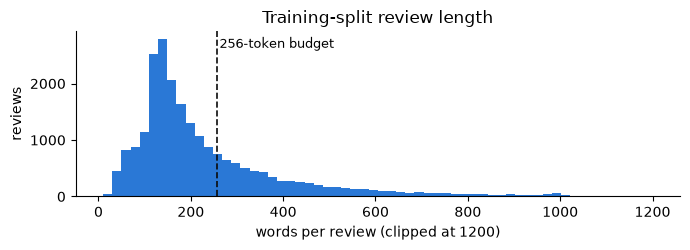

In [6]:
import matplotlib.pyplot as plt
n = train["text"].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.hist(n.clip(upper=1200), bins=60, color="#2a78d6")
ax.axvline(256, color="#0b0b0b", ls="--", lw=1.2)
ax.text(262, ax.get_ylim()[1] * .9, "256-token budget", fontsize=9)
ax.set(xlabel="words per review (clipped at 1200)", ylabel="reviews", title="Training-split review length")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); fig.savefig(FIG / "review_length_hist.png", dpi=200); plt.show()

## 4. Vocabulary and GloVe matrix (Text CNN and BiLSTM)
Vocabulary is built from the **training split only** (frequency ≥ 2, ≤ 50k words, plus `<pad>`=0 and `<unk>`=1). Rows for words found in GloVe are copied; other rows are drawn from N(0, 0.1); the padding row is zero.

In [7]:
import json
TOKEN = re.compile(r"[a-z0-9]+(?=n't)|n't|'(?:s|m|re|ve|ll|d)\b|[a-z0-9]+|[!?]")   # splits contractions like GloVe (didn't -> did n't), keeps ! ?
counts = Counter(tok for t in train["text"] for tok in TOKEN.findall(t))
words = [w for w, c in counts.most_common(MAX_VOCAB - 2) if c >= MIN_FREQ]
vocab = {"<pad>": 0, "<unk>": 1, **{w: i + 2 for i, w in enumerate(words)}}

rng = np.random.default_rng(SEED)
matrix = rng.normal(0, 0.1, (len(vocab), 300)).astype(np.float32)
matrix[0] = 0
found = set()
with open(GLOVE, encoding="utf-8") as f:
    for line in f:
        word, rest = line.split(" ", 1)
        idx = vocab.get(word)
        if idx is not None and idx > 1:
            matrix[idx] = np.asarray(rest.split(), dtype=np.float32)
            found.add(word)

(PROC / "vocab.json").write_text(json.dumps(vocab))
np.save(PROC / "glove_300d_matrix.npy", matrix)
missing = [w for w in words if w not in found]
token_cov = sum(counts[w] for w in found) / sum(counts[w] for w in words)
print(f"vocabulary {len(vocab):,} | GloVe type coverage {len(found) / len(words):.1%} | token coverage {token_cov:.1%}")
print("most frequent words without a GloVe vector:", missing[:15])

vocabulary 44,912 | GloVe type coverage 94.4% | token coverage 99.8%
most frequent words without a GloVe vector: ['gypo', 'feinstone', 'imho', 'ossessione', 'zelah', 'paperhouse', 'carface', 'trelkovsky', 'pazu', 'sheeta', 'hackenstein', 'malefique', 'todesking', 'buttgereit', 'grisby']


# Preprocessing checks

Before training, verify that the generated train, validation, and test splits have stable row counts and matching label encodings. These checks are intended to catch accidental split drift when the shared pipeline is rerun.
